In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from collections import deque
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================
# 1. SETUP AND SEEDS
# ============================================

# Set global random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Global random seeds set to {SEED}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Global random seeds set to 42
CUDA available: True
GPU: NVIDIA GeForce GTX 1050
Using device: cuda


In [4]:
# ============================================
# 2. DATA LOADING AND PREPROCESSING
# ============================================

# Load data
df_raw = pd.read_csv('EXS1.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').set_index('Date')

# Handle missing values
df_raw['EXS1_Close'] = df_raw['EXS1_Close'].ffill()

# Extract only closing prices
stoxx50_data = df_raw[['EXS1_Close']].copy()

print(f"Total data points: {len(stoxx50_data)}")
print(f"Date range: {stoxx50_data.index.min()} to {stoxx50_data.index.max()}")

# Train-test split (last 30 days for testing)
test_size = 30
train_data_stoxx50 = stoxx50_data[:-test_size]
test_data_stoxx50 = stoxx50_data[-test_size:]

print(f"\nTraining set: {len(train_data_stoxx50)} points")
print(f"Test set: {len(test_data_stoxx50)} points")
print(f"Train date range: {train_data_stoxx50.index.min()} to {train_data_stoxx50.index.max()}")
print(f"Test date range: {test_data_stoxx50.index.min()} to {test_data_stoxx50.index.max()}")

# Initialize scaler (fit on training data only)
stoxx50_scaler = MinMaxScaler(feature_range=(0, 1))
stoxx50_scaler.fit(train_data_stoxx50.values.reshape(-1, 1))


Total data points: 4517
Date range: 2008-01-02 00:00:00 to 2025-10-09 00:00:00

Training set: 4487 points
Test set: 30 points
Train date range: 2008-01-02 00:00:00 to 2025-08-28 00:00:00
Test date range: 2025-08-29 00:00:00 to 2025-10-09 00:00:00


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [5]:
# ============================================
# 3. SIMPLE LSTM MODEL (ORIGINAL ARCHITECTURE)
# ============================================

class SimpleLSTMModel(nn.Module):
    """
    Simple LSTM model - same as original
    """
    def __init__(self, input_size, hidden_layer_size, output_size_fixed, dropout_rate):
        super(SimpleLSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        
        # Single LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        
        # Single linear output layer
        self.fc = nn.Linear(hidden_layer_size, output_size_fixed)
        
    def forward(self, x):
        # Initialize hidden state and cell state
        h0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        # Take only the last time step
        last_output = lstm_out[:, -1, :]
        
        # Apply dropout
        dropout_out = self.dropout(last_output)
        
        # Final linear layer
        output = self.fc(dropout_out)
        
        return output


In [6]:
# ============================================
# 4. PROPER TIME SERIES CROSS-VALIDATION FUNCTION
# ============================================

def create_proper_time_series_cv_splits(data, n_splits=5, min_train_frac=0.2):
    """
    Creates proper expanding window time series cross-validation splits.
    """
    total_len = len(data)
    min_train = int(total_len * min_train_frac)
    
    cv_splits = []
    
    for i in range(n_splits):
        # Training size expands with each fold
        train_end_idx = min_train + int((total_len - min_train) * (i + 1) / (n_splits + 1))
        
        # Validation is the next segment
        val_start_idx = train_end_idx
        val_end_idx = min_train + int((total_len - min_train) * (i + 2) / (n_splits + 1))
        
        # Cap at total length
        if val_end_idx > total_len:
            val_end_idx = total_len
        
        # Skip if no validation data
        if val_start_idx >= val_end_idx:
            continue
        
        # Get date ranges
        train_dates = (data.index[0], data.index[train_end_idx - 1])
        validation_dates = (data.index[val_start_idx], data.index[val_end_idx - 1])
        
        cv_splits.append({
            'train_dates': train_dates,
            'validation_dates': validation_dates,
            'train_size': train_end_idx,
            'val_size': val_end_idx - val_start_idx
        })
    
    print(f"Created {len(cv_splits)} CV splits with expanding window:")
    for i, split in enumerate(cv_splits):
        print(f"  Fold {i+1}: Train {split['train_size']} days, Val {split['val_size']} days")
    
    return cv_splits


In [7]:
# ============================================
# 5. SEQUENCE PREPARATION FUNCTION (FIXED)
# ============================================

def prepare_sequences_5_output(data_series, seq_length, forecast_horizon=5):
    """
    Creates input-output sequences for multi-step forecasting.
    Accepts both DataFrame and Series input.
    """
    # Handle both DataFrame and Series input
    if isinstance(data_series, pd.DataFrame):
        values = data_series['EXS1_Close'].values
    elif isinstance(data_series, pd.Series):
        values = data_series.values
    else:
        values = data_series
    
    # Scale the data using pre-fitted scaler
    scaled_data = stoxx50_scaler.transform(values.reshape(-1, 1)).flatten()
    
    X_list, y_list = [], []
    
    # Create sliding windows
    # FIX: Ensure we're using integers in range()
    data_length = len(scaled_data)
    if data_length >= seq_length + forecast_horizon:
        for i in range(int(data_length) - seq_length - forecast_horizon + 1):
            X_list.append(scaled_data[i:(i + seq_length)])
            y_list.append(scaled_data[(i + seq_length):(i + seq_length + forecast_horizon)])
    
    # Convert to arrays
    X = np.array(X_list)
    y = np.array(y_list)
    
    # Reshape X for LSTM: (samples, seq_length, features)
    if X.shape[0] > 0:
        X = X.reshape(X.shape[0], X.shape[1], 1)
    else:
        X = np.empty((0, seq_length, 1))
    
    # Ensure y has correct shape
    if y.shape[0] == 0:
        y = np.empty((0, forecast_horizon))
    
    return X, y


In [8]:
# ============================================
# 6. DATASET CLASS
# ============================================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [9]:
# ============================================
# 7. TRAINING FUNCTION WITH EARLY STOPPING
# ============================================

def train_and_evaluate_simple(model, train_loader, val_loader, optimizer, criterion, 
                             epochs, device, patience, model_path):
    """
    Trains simple LSTM model with early stopping.
    Returns scaled RMSE only (0-1 range).
    """
    best_val_rmse = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_rmse': [], 'val_rmse': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_rmse = np.sqrt(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader:
                X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
                outputs_val = model(X_batch_val)
                val_loss = criterion(outputs_val, y_batch_val)
                val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_rmse = np.sqrt(avg_val_loss)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_rmse'].append(avg_train_rmse)
        history['val_rmse'].append(avg_val_rmse)
        
        # Early stopping logic
        if avg_val_rmse < best_val_rmse:
            best_val_rmse = avg_val_rmse
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                break
    
    # Load best model
    model.load_state_dict(torch.load(model_path))
    
    return best_val_rmse, history


In [10]:
# ============================================
# 8. HYPERPARAMETER TUNING WITH 5-FOLD CV
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING WITH 5-FOLD TIME SERIES CV")
print("="*60)

# Define hyperparameter grid (same as before)
hyperparameter_grid = {
    'lstm_units': [32, 64],
    'dropout_rate': [0.2, 0.5],
    'seq_length': [22, 66, 132]
}

# Create 5-fold CV splits
n_splits = 5
cv_splits = create_proper_time_series_cv_splits(train_data_stoxx50, n_splits=n_splits)

# Store all results
all_results = []

# Iterate over hyperparameter combinations
for lstm_units in hyperparameter_grid['lstm_units']:
    for dropout_rate in hyperparameter_grid['dropout_rate']:
        for seq_length in hyperparameter_grid['seq_length']:
            
            print(f"\nTesting: LSTM Units={lstm_units}, Dropout={dropout_rate}, Seq Length={seq_length}")
            fold_rmses = []
            
            # Iterate over CV folds
            for fold_idx, split in enumerate(cv_splits):
                # Extract fold data
                train_fold = train_data_stoxx50.loc[
                    split['train_dates'][0]:split['train_dates'][1]
                ]
                val_fold = train_data_stoxx50.loc[
                    split['validation_dates'][0]:split['validation_dates'][1]
                ]
                
                # Check if enough data for sequences
                if len(train_fold) < seq_length + 5 or len(val_fold) < seq_length + 5:
                    continue
                
                # Prepare sequences
                X_train_fold, y_train_fold = prepare_sequences_5_output(train_fold, seq_length)
                X_val_fold, y_val_fold = prepare_sequences_5_output(val_fold, seq_length)
                
                if len(X_train_fold) == 0 or len(X_val_fold) == 0:
                    continue
                
                # Create DataLoaders
                train_dataset = TimeSeriesDataset(X_train_fold, y_train_fold)
                val_dataset = TimeSeriesDataset(X_val_fold, y_val_fold)
                
                train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
                val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
                
                # Initialize SIMPLE LSTM model
                model = SimpleLSTMModel(
                    input_size=1,
                    hidden_layer_size=lstm_units,
                    output_size_fixed=5,
                    dropout_rate=dropout_rate
                ).to(device)
                
                # Define optimizer and loss
                optimizer = optim.Adam(model.parameters(), lr=0.01)
                criterion = nn.MSELoss()
                
                # Train and evaluate
                model_path = f'temp_simple_model_fold_{fold_idx}.pth'
                val_rmse, _ = train_and_evaluate_simple(
                    model, train_loader, val_loader, optimizer, criterion,
                    epochs=100, device=device, patience=20, model_path=model_path
                )
                
                fold_rmses.append(val_rmse)
            
            # Calculate average RMSE for this hyperparameter combination
            if fold_rmses:
                avg_rmse = np.mean(fold_rmses)
                std_rmse = np.std(fold_rmses)
                
                # Store results
                all_results.append({
                    'lstm_units': lstm_units,
                    'dropout_rate': dropout_rate,
                    'seq_length': seq_length,
                    'avg_val_rmse': avg_rmse,
                    'std_val_rmse': std_rmse,
                    'n_folds': len(fold_rmses)
                })
                
                print(f"  Average RMSE: {avg_rmse:.6f} (±{std_rmse:.6f})")



HYPERPARAMETER TUNING WITH 5-FOLD TIME SERIES CV
Created 5 CV splits with expanding window:
  Fold 1: Train 1495 days, Val 598 days
  Fold 2: Train 2093 days, Val 599 days
  Fold 3: Train 2692 days, Val 598 days
  Fold 4: Train 3290 days, Val 598 days
  Fold 5: Train 3888 days, Val 599 days

Testing: LSTM Units=32, Dropout=0.2, Seq Length=22
  Average RMSE: 0.028297 (±0.024431)

Testing: LSTM Units=32, Dropout=0.2, Seq Length=66
  Average RMSE: 0.031969 (±0.032311)

Testing: LSTM Units=32, Dropout=0.2, Seq Length=132
  Average RMSE: 0.017392 (±0.000919)

Testing: LSTM Units=32, Dropout=0.5, Seq Length=22
  Average RMSE: 0.016271 (±0.002801)

Testing: LSTM Units=32, Dropout=0.5, Seq Length=66
  Average RMSE: 0.018379 (±0.004534)

Testing: LSTM Units=32, Dropout=0.5, Seq Length=132
  Average RMSE: 0.020568 (±0.004126)

Testing: LSTM Units=64, Dropout=0.2, Seq Length=22
  Average RMSE: 0.056120 (±0.034652)

Testing: LSTM Units=64, Dropout=0.2, Seq Length=66
  Average RMSE: 0.040944 (±0.0

In [11]:
# ============================================
# 9. DISPLAY RESULTS IN TABLE FORMAT
# ============================================

print("\n" + "="*60)
print("CONSOLIDATED GRID SEARCH RESULTS")
print("="*60)

# Convert to DataFrame for nice display
results_df = pd.DataFrame(all_results)

# Sort by average validation RMSE (ascending)
results_df = results_df.sort_values('avg_val_rmse').reset_index(drop=True)

# Print results in table format (like XGBoost output)
print("\n--- Consolidated Grid Search Results (Sorted by Mean Validation RMSE) ---")
print(f"{'LSTM Units':<12} {'Dropout':<10} {'Seq Length':<12} {'Mean RMSE':<12} {'Std RMSE':<12} {'Folds':<6}")
print("-" * 68)

for _, row in results_df.iterrows():
    print(f"{row['lstm_units']:<12} {row['dropout_rate']:<10.2f} {row['seq_length']:<12} "
          f"{row['avg_val_rmse']:<12.6f} {row['std_val_rmse']:<12.6f} {row['n_folds']:<6}")

# Select best hyperparameters
best_row = results_df.iloc[0]
best_lstm_units = int(best_row['lstm_units'])
best_dropout_rate = float(best_row['dropout_rate'])
best_seq_length = int(best_row['seq_length'])
best_avg_rmse = best_row['avg_val_rmse']

# Calculate estimated original scale RMSE
price_range = train_data_stoxx50['EXS1_Close'].max() - train_data_stoxx50['EXS1_Close'].min()
estimated_original_rmse = best_avg_rmse * price_range

print(f"\n{'='*60}")
print(f"BEST HYPERPARAMETERS SELECTED:")
print(f"  LSTM Units:      {best_lstm_units}")
print(f"  Dropout Rate:    {best_dropout_rate}")
print(f"  Sequence Length: {best_seq_length}")
print(f"  Validation RMSE (scaled): {best_avg_rmse:.6f}")
print(f"  Estimated Original Scale RMSE: ~{estimated_original_rmse:.2f} points")
print(f"  (Training price range: {price_range:.2f} points)")
print(f"{'='*60}")



CONSOLIDATED GRID SEARCH RESULTS

--- Consolidated Grid Search Results (Sorted by Mean Validation RMSE) ---
LSTM Units   Dropout    Seq Length   Mean RMSE    Std RMSE     Folds 
--------------------------------------------------------------------
64.0         0.20       132.0        0.015832     0.002100     5.0   
32.0         0.50       22.0         0.016271     0.002801     5.0   
32.0         0.20       132.0        0.017392     0.000919     5.0   
32.0         0.50       66.0         0.018379     0.004534     5.0   
64.0         0.50       132.0        0.019416     0.005801     5.0   
32.0         0.50       132.0        0.020568     0.004126     5.0   
32.0         0.20       22.0         0.028297     0.024431     5.0   
32.0         0.20       66.0         0.031969     0.032311     5.0   
64.0         0.20       66.0         0.040944     0.030120     5.0   
64.0         0.50       22.0         0.041846     0.032123     5.0   
64.0         0.50       66.0         0.048842     0.

In [12]:
# =====================================
# 10. RECURSIVE RETRAINING ON TEST SET 
# =====================================

print("\n" + "="*60)
print("RECURSIVE RETRAINING ON TEST SET")
print("="*60)

# Parameters for recursive retraining
forecast_horizon = 5
num_test_blocks = len(test_data_stoxx50) // forecast_horizon

print(f"Test blocks to forecast: {num_test_blocks} (5 days each)")
print(f"Total test days: {len(test_data_stoxx50)}")

# Store predictions and actuals
all_predictions = []
all_actuals = []
block_metrics = []

# Start with initial training data as DataFrame
current_train = train_data_stoxx50.copy()

# Loop through each 5-day block
for block in range(num_test_blocks):
    print(f"\n=== Block {block + 1}/{num_test_blocks} ===")
    
    # Get actual values for this block
    start_idx = block * forecast_horizon
    end_idx = (block + 1) * forecast_horizon
    actual_block = test_data_stoxx50.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Predicting test days {start_idx + 1} to {end_idx}")
    
    # 1. Prepare sequences from current training data
    X_train, y_train = prepare_sequences_5_output(current_train, best_seq_length)
    
    if len(X_train) == 0:
        print("Warning: Not enough data to create sequences")
        break
    
    # 2. Create a small validation set from the end of training data
    # (for early stopping during retraining)
    val_split_early_stopping = 0.2
    val_size = max(1, int(len(X_train) * val_split_early_stopping))
    
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    X_val_final = X_train[-val_size:]
    y_val_final = y_train[-val_size:]
    
    # 3. Create DataLoaders
    train_dataset = TimeSeriesDataset(X_train_final, y_train_final)
    val_dataset = TimeSeriesDataset(X_val_final, y_val_final)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # 4. Train SIMPLE LSTM model on current training data
    print(f"Training simple LSTM on {len(current_train)} days...")
    
    model = SimpleLSTMModel(
        input_size=1,
        hidden_layer_size=best_lstm_units,
        output_size_fixed=forecast_horizon,
        dropout_rate=best_dropout_rate
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    model_path = f'simple_lstm_block_{block + 1}.pth'
    val_rmse, _ = train_and_evaluate_simple(
        model, train_loader, val_loader, optimizer, criterion,
        epochs=100, device=device, patience=20, model_path=model_path
    )
    
    # 5. Get last sequence for prediction
    last_sequence = current_train['EXS1_Close'].iloc[-best_seq_length:].values.reshape(-1, 1)
    last_sequence_scaled = stoxx50_scaler.transform(last_sequence)
    last_sequence_scaled = torch.tensor(
        last_sequence_scaled.reshape(1, best_seq_length, 1),
        dtype=torch.float32
    ).to(device)
    
    # 6. Make prediction for next 5 days
    with torch.no_grad():
        model.eval()
        pred_scaled = model(last_sequence_scaled).cpu().numpy().flatten()
    
    # Inverse transform predictions
    predictions = stoxx50_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).flatten()
    
    # 7. Store results
    all_predictions.extend(predictions)
    all_actuals.extend(actual_block['EXS1_Close'].values)
    
    # 8. Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block['EXS1_Close'].values, predictions))
    block_mae = mean_absolute_error(actual_block['EXS1_Close'].values, predictions)
    
    block_metrics.append({
        'block': block + 1,
        'training_size': len(current_train),
        'rmse': block_rmse,
        'mae': block_mae,
        'predictions': predictions,
        'actuals': actual_block['EXS1_Close'].values
    })
    
    print(f"Predictions: {predictions.round(2)}")
    print(f"Actuals:     {actual_block['EXS1_Close'].values.round(2)}")
    print(f"Block RMSE: {block_rmse:.2f}, MAE: {block_mae:.2f}")
    
    # 9. Add actual values to training data for next block
    if block < num_test_blocks - 1:
        # Convert actual_block to DataFrame and concatenate
        current_train = pd.concat([current_train, actual_block])
        print(f"Added {len(actual_block)} actual days to training data")



RECURSIVE RETRAINING ON TEST SET
Test blocks to forecast: 6 (5 days each)
Total test days: 30

=== Block 1/6 ===
Training size: 4487 days
Predicting test days 1 to 5
Training simple LSTM on 4487 days...
Predictions: [184.79 185.57 184.68 185.49 184.49]
Actuals:     [198.12 199.18 194.54 195.38 196.9 ]
Block RMSE: 11.93, MAE: 11.82
Added 5 actual days to training data

=== Block 2/6 ===
Training size: 4492 days
Predicting test days 6 to 10
Training simple LSTM on 4492 days...
Predictions: [200.01 200.55 200.14 199.45 199.64]
Actuals:     [195.56 197.22 196.44 195.8  196.4 ]
Block RMSE: 3.70, MAE: 3.67
Added 5 actual days to training data

=== Block 3/6 ===
Training size: 4497 days
Predicting test days 11 to 15
Training simple LSTM on 4497 days...
Predictions: [188.02 187.54 188.18 187.96 187.81]
Actuals:     [196.3  196.78 193.3  193.58 196.24]
Block RMSE: 7.52, MAE: 7.34
Added 5 actual days to training data

=== Block 4/6 ===
Training size: 4502 days
Predicting test days 16 to 20
Trai

In [13]:
# ============================================
# 11. EVALUATION AND METRICS
# ============================================

print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

# Flatten predictions and actuals
all_predictions_flat = np.array(all_predictions)
all_actuals_flat = np.array(all_actuals)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': all_actuals_flat,
    'LSTM_Predicted': all_predictions_flat
}, index=test_data_stoxx50.iloc[:len(all_predictions_flat)].index)

print(f"\nPredictions vs Actuals (first 10 days):")
print(comparison_df.head(10).round(2))

# Calculate cumulative metrics for different horizons
print(f"\n{'='*60}")
print("CUMULATIVE PERFORMANCE BY HORIZON")
print(f"{'='*60}")

# Define standard horizons
standard_horizons = [5, 10, 15, 20, 25, 30]
actual_horizon = len(all_actuals_flat)

print(f"\nTotal test days: {actual_horizon}")
print("\nCumulative Performance (from Day 1):")
for h in standard_horizons:
    if h <= actual_horizon:
        # Take first h days and calculate directly
        actuals_h = all_actuals_flat[:h]
        preds_h = all_predictions_flat[:h]
        
        rmse = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae = mean_absolute_error(actuals_h, preds_h)
        
        print(f"Horizon {h:2d} days - RMSE: {rmse:7.2f}, MAE: {mae:7.2f}")

# Overall performance
overall_rmse = np.sqrt(mean_squared_error(all_actuals_flat, all_predictions_flat))
overall_mae = mean_absolute_error(all_actuals_flat, all_predictions_flat)

print(f"\nOverall {actual_horizon}-day performance:")
print(f"RMSE: {overall_rmse:.2f}, MAE: {overall_mae:.2f}")



FINAL EVALUATION

Predictions vs Actuals (first 10 days):
            Actual  LSTM_Predicted
Date                              
2025-08-29  198.12      184.789993
2025-09-01  199.18      185.570007
2025-09-02  194.54      184.679993
2025-09-03  195.38      185.490005
2025-09-04  196.90      184.490005
2025-09-05  195.56      200.009995
2025-09-08  197.22      200.550003
2025-09-09  196.44      200.139999
2025-09-10  195.80      199.449997
2025-09-11  196.40      199.639999

CUMULATIVE PERFORMANCE BY HORIZON

Total test days: 30

Cumulative Performance (from Day 1):
Horizon  5 days - RMSE:   11.93, MAE:   11.82
Horizon 10 days - RMSE:    8.83, MAE:    7.75
Horizon 15 days - RMSE:    8.42, MAE:    7.61
Horizon 20 days - RMSE:    8.17, MAE:    7.55
Horizon 25 days - RMSE:    7.45, MAE:    6.45
Horizon 30 days - RMSE:    6.93, MAE:    5.84

Overall 30-day performance:
RMSE: 6.93, MAE: 5.84


In [14]:
# ===================
# 12. EXPORT RESULTS 
# ===================

# Export Results
comparison_df.to_csv('lstm.csv', index=True)
print(f"\n{'='*50}")
print("EXPORTING RESULTS")
print(f"{'='*50}")
print("Results exported to 'lstm.csv'")

# Show first few rows of the exported file
print("\nFirst 5 rows of exported CSV:")
print(pd.read_csv('lstm.csv').head())



EXPORTING RESULTS
Results exported to 'lstm.csv'

First 5 rows of exported CSV:
         Date      Actual  LSTM_Predicted
0  2025-08-29  198.119995       184.79352
1  2025-09-01  199.179993       185.56917
2  2025-09-02  194.539993       184.67691
3  2025-09-03  195.380005       185.49187
4  2025-09-04  196.899994       184.48914


In [15]:
# ==================
# 13. FINAL SUMMARY
# ==================

print(f"\n{'='*50}")
print("FORECASTING STRATEGY SUMMARY")
print(f"{'='*50}")
print(f"Forecasting Strategy: Recursive Retraining with Simple LSTM")
print(f"Best seq_length identified: {best_seq_length}")
print(f"Fixed forecast horizon: {forecast_horizon} days per block")
print(f"\nBest LSTM Hyperparameters:")
print(f"  LSTM Units:      {best_lstm_units}")
print(f"  Dropout Rate:    {best_dropout_rate}")
print(f"  Sequence Length: {best_seq_length}")
print(f"\nPerformance Metrics (using overall best parameters):")

# Display metrics for each horizon
print(f"\nCumulative Horizon Performance:")
for h in standard_horizons:
    if h <= actual_horizon:
        actuals_h = all_actuals_flat[:h]
        preds_h = all_predictions_flat[:h]
        
        rmse = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae = mean_absolute_error(actuals_h, preds_h)
        
        print(f"  {h}-day horizon - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

print(f"\nOverall {actual_horizon}-day performance:")
print(f"  RMSE: {overall_rmse:.2f}, MAE: {overall_mae:.2f}")

# Block-by-block summary
print(f"\nBlock-by-block training sizes:")
for metric in block_metrics:
    print(f"  Block {metric['block']}: Trained on {metric['training_size']} days")

print(f"\n{'='*60}")
print("SIMPLE LSTM RECURSIVE RETRAINING COMPLETE")
print(f"{'='*60}")



FORECASTING STRATEGY SUMMARY
Forecasting Strategy: Recursive Retraining with Simple LSTM
Best seq_length identified: 132
Fixed forecast horizon: 5 days per block

Best LSTM Hyperparameters:
  LSTM Units:      64
  Dropout Rate:    0.2
  Sequence Length: 132

Performance Metrics (using overall best parameters):

Cumulative Horizon Performance:
  5-day horizon - RMSE: 11.93, MAE: 11.82
  10-day horizon - RMSE: 8.83, MAE: 7.75
  15-day horizon - RMSE: 8.42, MAE: 7.61
  20-day horizon - RMSE: 8.17, MAE: 7.55
  25-day horizon - RMSE: 7.45, MAE: 6.45
  30-day horizon - RMSE: 6.93, MAE: 5.84

Overall 30-day performance:
  RMSE: 6.93, MAE: 5.84

Block-by-block training sizes:
  Block 1: Trained on 4487 days
  Block 2: Trained on 4492 days
  Block 3: Trained on 4497 days
  Block 4: Trained on 4502 days
  Block 5: Trained on 4507 days
  Block 6: Trained on 4512 days

SIMPLE LSTM RECURSIVE RETRAINING COMPLETE



VISUALIZATION


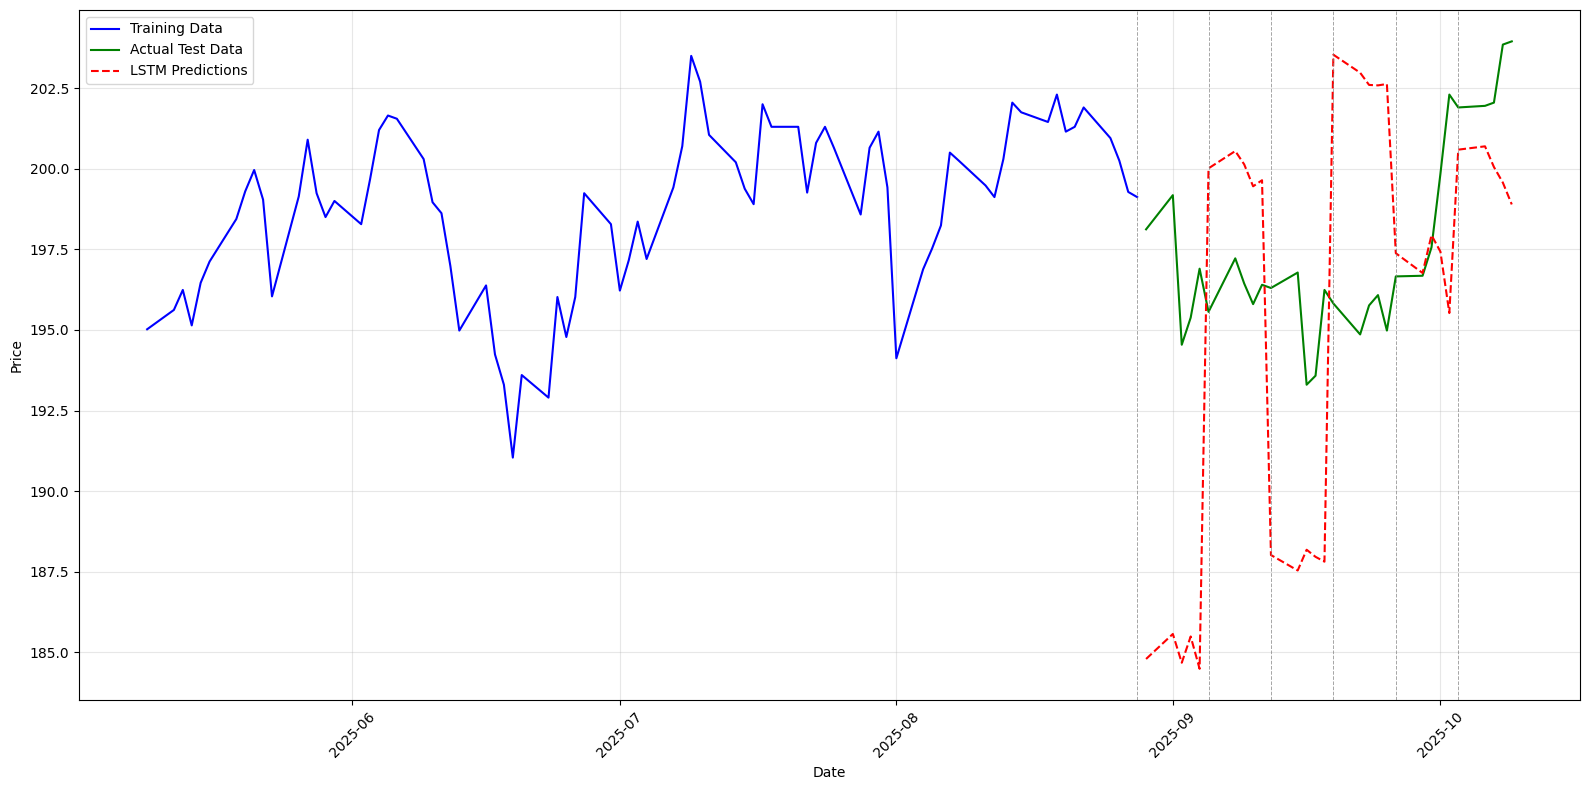

In [16]:
# ==================
# 14. VISUALIZATION
# ==================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Determine date range for last 5 months
end_date_plot = test_data_stoxx50.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting
train_data_plot = train_data_stoxx50[train_data_stoxx50.index >= start_date_plot]
actual_test_data_plot = test_data_stoxx50[test_data_stoxx50.index >= start_date_plot]
predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot
plt.figure(figsize=(16, 8))

# Plot training data
plt.plot(train_data_plot.index, train_data_plot['EXS1_Close'], 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data
plt.plot(actual_test_data_plot.index, actual_test_data_plot['EXS1_Close'], 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot predicted test data
plt.plot(predicted_data_plot.index, predicted_data_plot['LSTM_Predicted'], 
         label='LSTM Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(x=train_data_stoxx50.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries
for i in range(1, num_test_blocks):
    block_boundary = test_data_stoxx50.index[i * forecast_horizon]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
